In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing(as_frame=True)

data = housing.frame

print(data.head())
print("\nDataset Shape:", data.shape)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset Shape: (20640, 9)


In [3]:
X = data.drop("MedHouseVal", axis=1)
y = data["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [5]:
y_pred = model.predict(X_test)

In [6]:
print("\nModel Performance")
print("----------------------------")
print("R² Score :", round(r2_score(y_test, y_pred), 4))
print("MSE      :", round(mean_squared_error(y_test, y_pred), 4))
print("RMSE     :", round(mean_squared_error(y_test, y_pred) ** 0.5, 4))


Model Performance
----------------------------
R² Score : 0.5758
MSE      : 0.5559
RMSE     : 0.7456


In [7]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print("\nFeature Importance (Coefficients)")
print(coef)



Feature Importance (Coefficients)
      Feature  Coefficient
0      MedInc     0.448675
1    HouseAge     0.009724
2    AveRooms    -0.123323
3   AveBedrms     0.783145
4  Population    -0.000002
5    AveOccup    -0.003526
6    Latitude    -0.419792
7   Longitude    -0.433708


In [8]:
sample_house = X.iloc[[0]]

predicted_price = model.predict(sample_house)

print("\nPredicted House Price:")
print(f"${predicted_price[0] * 100000:.2f}")

print("Actual House Price:")
print(f"${y.iloc[0] * 100000:.2f}")


Predicted House Price:
$415194.27
Actual House Price:
$452600.00


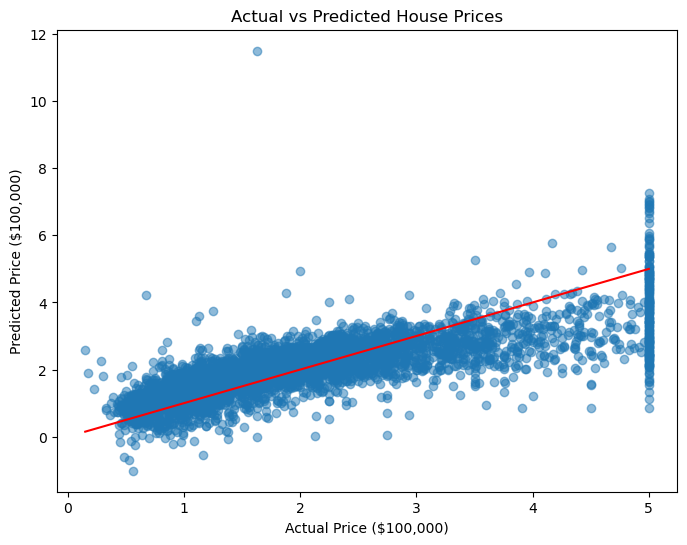

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Price ($100,000)")
plt.ylabel("Predicted Price ($100,000)")
plt.title("Actual vs Predicted House Prices")

xmin = min(y_test)
xmax = max(y_test)

plt.plot([xmin, xmax], [xmin, xmax], 'r')
plt.show()


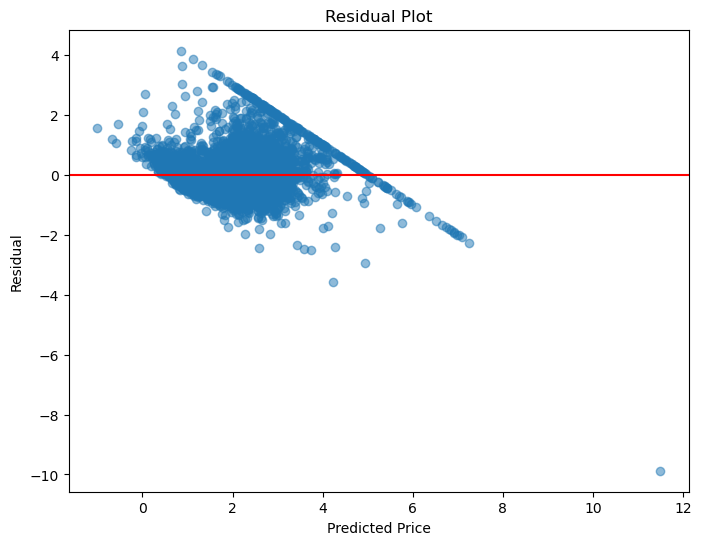

In [10]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, color='r')

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()